# Financial Fraud Detection Using XGBoost

## 1. Business Problem

The objective is to develop a machine learning model capable of identifying fraudulent financial transactions in a highly imbalanced dataset.

The project focuses on:
- Detecting as many fraudulent transactions as possible
- Minimising false positives
- Using transaction-level behavioural and balance features
- Evaluating the model using precision, recall and F1-score

## 2. Data Loading & Understanding

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Users/falesh/Data Science/Projects/fraud-risk-scoring/data/PS_20174392719_1491204439457_log.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [50]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00
isFlaggedFraud,6362620.0,2.514687e-06,1.585775e-03,0.0,0.00,0.000,0.000000e+00,1.000000e+00


In [7]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate rows: 0


## 3. Fraud Distribution

In [8]:
fraud_counts = df["isFraud"].value_counts()

print(fraud_counts)

print("\nFraud proportion:")
print(df["isFraud"].value_counts(normalize=True))

isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud proportion:
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


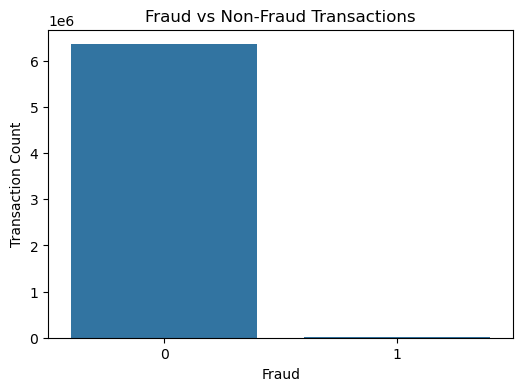

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="isFraud")

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud")
plt.ylabel("Transaction Count")
plt.show()

## 4. Transaction Type Analysis

In [10]:
fraud_by_type = (
    df.groupby("type")["isFraud"]
      .agg(["count", "sum", "mean"])
      .sort_values("mean", ascending=False)
)

fraud_by_type.columns = [
    "transaction_count",
    "fraud_count",
    "fraud_rate"
]

fraud_by_type

,transaction_count,fraud_count,fraud_rate
type,,,
TRANSFER,532909,4097,0.007688
CASH_OUT,2237500,4116,0.001840
CASH_IN,1399284,0,0.000000
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000


In [11]:
pd.crosstab(df["type"], df["isFraud"])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


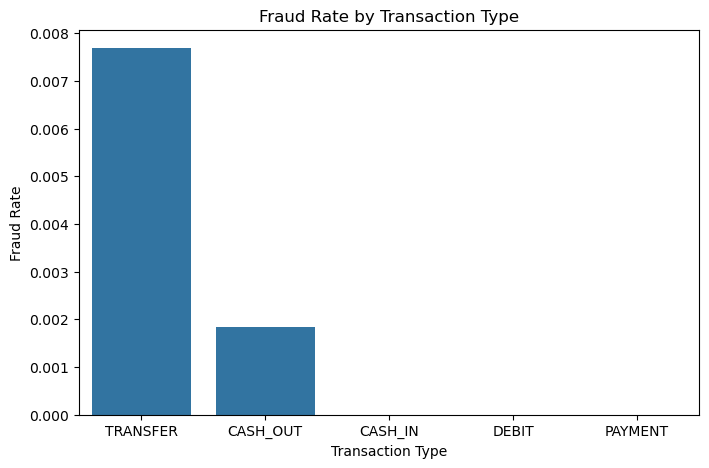

In [12]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=fraud_by_type.reset_index(),
    x="type",
    y="fraud_rate"
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")
plt.show()

## 5. Feature Engineering

In [13]:
df["balance_change_orig"] = (
    df["oldbalanceOrg"] - df["newbalanceOrig"]
)

df["balance_change_dest"] = (
    df["newbalanceDest"] - df["oldbalanceDest"]
)

df["amount_to_balance_ratio"] = (
    df["amount"] / (df["oldbalanceOrg"] + 1)
)

df["origin_balance_error"] = (
    df["oldbalanceOrg"]
    - df["amount"]
    - df["newbalanceOrig"]
)

df["destination_balance_error"] = (
    df["oldbalanceDest"]
    + df["amount"]
    - df["newbalanceDest"]
)

df["is_zero_balance_orig"] = (
    df["newbalanceOrig"] == 0
).astype(int)

In [14]:
df["hour"] = df["step"] % 24

df["day"] = df["step"] // 24

df["is_night"] = (
    (df["hour"] < 6) |
    (df["hour"] >= 22)
).astype(int)

In [15]:
engineered_features = [
    "balance_change_orig",
    "balance_change_dest",
    "amount_to_balance_ratio",
    "origin_balance_error",
    "destination_balance_error",
    "is_zero_balance_orig",
    "hour",
    "day",
    "is_night"
]

df[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
balance_change_orig,6362620.0,-21230.564504,146643.286486,-1915267.90,0.000000,0.000000,10150.435,1.000000e+07
balance_change_dest,6362620.0,124294.731682,812939.081063,-13060826.21,0.000000,0.000000,149105.425,1.056878e+08
amount_to_balance_ratio,6362620.0,70674.476792,508424.269379,0.00,0.234401,6.453832,12287.765,9.244552e+07
origin_balance_error,6362620.0,-201092.468053,606650.460137,-92445516.64,-249641.087500,-68677.255000,-2954.230,1.000000e-02
destination_balance_error,6362620.0,55567.171867,441528.768815,-75885725.63,0.000000,3500.490000,29353.045,1.319123e+07
is_zero_balance_orig,6362620.0,0.567308,0.495449,0.00,0.000000,1.000000,1.000,1.000000e+00
hour,6362620.0,15.321454,4.321799,0.00,12.000000,16.000000,19.000,2.300000e+01
day,6362620.0,9.503158,5.922111,0.00,6.000000,9.000000,13.000,3.000000e+01
is_night,6362620.0,0.070477,0.255949,0.00,0.000000,0.000000,0.000,1.000000e+00


## 6. Time-Based Train/Test Split

In [16]:
split_step = int(df["step"].quantile(0.8))

train_df = df[df["step"] <= split_step].copy()
test_df = df[df["step"] > split_step].copy()

X_train = train_df.drop(columns=["isFraud"])
y_train = train_df["isFraud"]

X_test = test_df.drop(columns=["isFraud"])
y_test = test_df["isFraud"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print(
    "Train step range:",
    X_train["step"].min(),
    "-",
    X_train["step"].max()
)

print(
    "Test step range:",
    X_test["step"].min(),
    "-",
    X_test["step"].max()
)

Train shape: (5113884, 19)
Test shape: (1248736, 19)
Train step range: 1 - 355
Test step range: 356 - 743


## 7. Baseline Model

In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

baseline_features = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

X_train_baseline = X_train[baseline_features]
X_test_baseline = X_test[baseline_features]

In [19]:
baseline_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    colsample_bytree=0.8,
    n_jobs=-1,
    eval_metric="aucpr"
)

baseline_model.fit(
    X_train_baseline,
    y_train
)

y_pred_baseline = baseline_model.predict(
    X_test_baseline
)

print(classification_report(
    y_test,
    y_pred_baseline
))

print(confusion_matrix(
    y_test,
    y_pred_baseline
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1244486
           1       1.00      0.59      0.74      4250

    accuracy                           1.00   1248736
   macro avg       1.00      0.79      0.87   1248736
weighted avg       1.00      1.00      1.00   1248736

[[1244474      12]
 [   1758    2492]]


## 8. Engineered XGBoost Model

In [20]:
engineered_features = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "balance_change_orig",
    "balance_change_dest",
    "amount_to_balance_ratio",
    "origin_balance_error",
    "destination_balance_error",
    "is_zero_balance_orig",
    "hour",
    "day",
    "is_night"
]

X_train_engineered = X_train[engineered_features]
X_test_engineered = X_test[engineered_features]

In [21]:
engineered_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    colsample_bytree=0.8,
    n_jobs=-1,
    eval_metric="aucpr"
)

engineered_model.fit(
    X_train_engineered,
    y_train
)

y_pred_engineered = engineered_model.predict(
    X_test_engineered
)

print(classification_report(
    y_test,
    y_pred_engineered
))

print(confusion_matrix(
    y_test,
    y_pred_engineered
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1244486
           1       1.00      1.00      1.00      4250

    accuracy                           1.00   1248736
   macro avg       1.00      1.00      1.00   1248736
weighted avg       1.00      1.00      1.00   1248736

[[1244486       0]
 [      3    4247]]


## 9. Model Comparison

Both models are compared using the default classification threshold of 0.5.

In [22]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline XGBoost",
        "Engineered XGBoost"
    ],
    "Fraud Precision": [
        1.00,
        1.00
    ],
    "Fraud Recall": [
        0.59,
        4247 / 4250
    ],
    "Fraud F1": [
        0.74,
        2 * (1.00 * (4247 / 4250)) / (1.00 + (4247 / 4250))
    ],
    "False Positives": [
        12,
        0
    ],
    "False Negatives": [
        1758,
        3
    ]
})

comparison

,Model,Fraud Precision,Fraud Recall,Fraud F1,False Positives,False Negatives
0,Baseline XGBoost,1.0,0.590000,0.740000,12,1758
1,Engineered XGBoost,1.0,0.999294,0.999647,0,3


## 10. Validation Set & Threshold Optimisation

In [37]:
from sklearn.metrics import precision_recall_curve

# Split training data chronologically into train and validation
validation_step = int(train_df["step"].quantile(0.8))

model_train_df = train_df[train_df["step"] <= validation_step]
validation_df = train_df[train_df["step"] > validation_step]

X_model_train = model_train_df[engineered_features]
y_model_train = model_train_df["isFraud"]

X_validation = validation_df[engineered_features]
y_validation = validation_df["isFraud"]

print("Model training shape:", X_model_train.shape)
print("Validation shape:", X_validation.shape)

print(
    "Model training step range:",
    X_model_train["step"].min(),
    "-",
    X_model_train["step"].max()
)

print(
    "Validation step range:",
    X_validation["step"].min(),
    "-",
    X_validation["step"].max()
)

Model training shape: (4104531, 15)
Validation shape: (1009353, 15)
Model training step range: 1 - 301
Validation step range: 302 - 355


In [38]:
validation_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    colsample_bytree=0.8,
    n_jobs=-1,
    eval_metric="aucpr"
)

validation_model.fit(
    X_model_train,
    y_model_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

In [39]:
y_validation_prob = validation_model.predict_proba(
    X_validation
)[:, 1]

In [40]:
precision, recall, thresholds = precision_recall_curve(
    y_validation,
    y_validation_prob
)

f1 = (
    2 * precision * recall
    / (precision + recall + 1e-10)
)

best_idx = f1.argmax()

best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Validation Precision:", precision[best_idx])
print("Validation Recall:", recall[best_idx])
print("Validation F1:", f1[best_idx])

Best threshold: 0.9193394
Validation Precision: 0.998211091234347
Validation Recall: 1.0
Validation F1: 0.9991047448022828


## 11. Final Model Evaluation

In [27]:
final_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    colsample_bytree=0.8,
    n_jobs=-1,
    eval_metric="aucpr"
)

final_model.fit(
    X_train_engineered,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

In [41]:
y_test_prob = final_model.predict_proba(
    X_test_engineered
)[:, 1]

In [42]:
y_pred_final = (
    y_test_prob >= best_threshold
).astype(int)

In [43]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(
    y_test,
    y_pred_final
))

print("Confusion Matrix:")
print(confusion_matrix(
    y_test,
    y_pred_final
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1244486
           1       1.00      1.00      1.00      4250

    accuracy                           1.00   1248736
   macro avg       1.00      1.00      1.00   1248736
weighted avg       1.00      1.00      1.00   1248736

Confusion Matrix:
[[1244486       0]
 [      3    4247]]


## 12. Model Explainability — SHAP

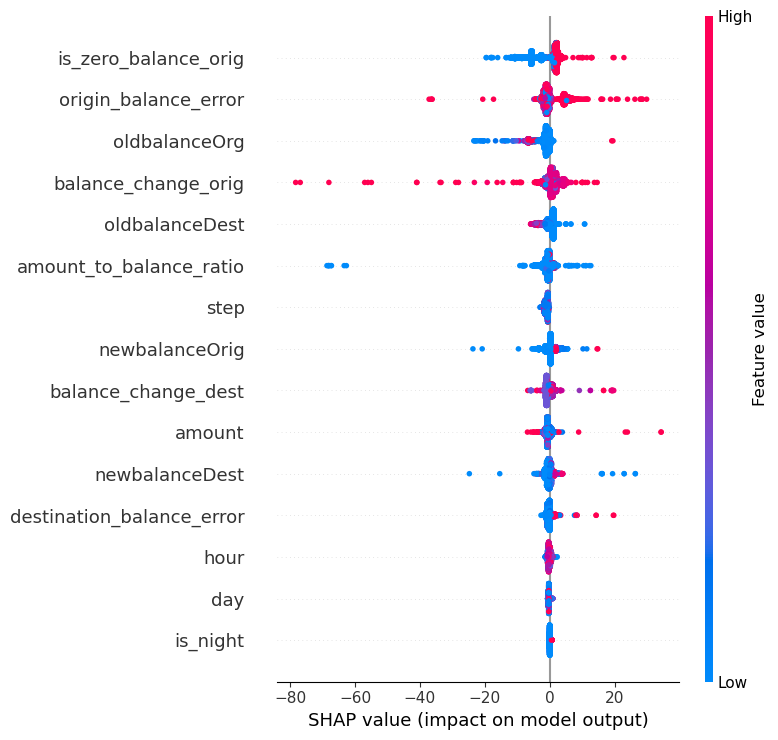

In [44]:
import shap

explainer = shap.TreeExplainer(final_model)

# Use a sample because the full test set is very large
X_shap = X_test_engineered.sample(
    5000,
    random_state=42
)

shap_values = explainer(X_shap)

shap.summary_plot(
    shap_values,
    X_shap
)

## 13. Precision–Recall Curve

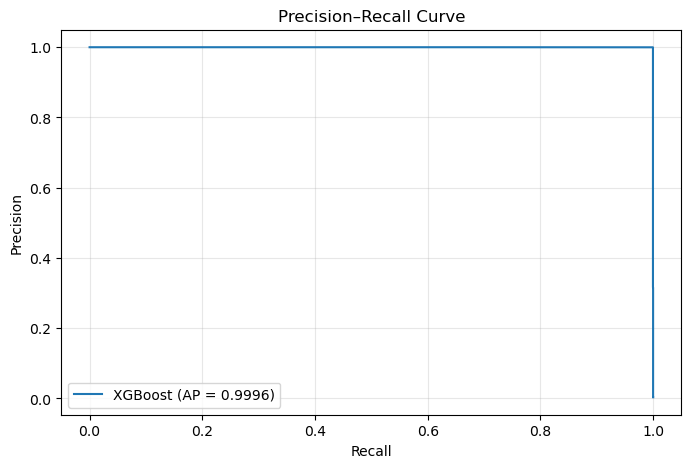

Average Precision: 0.9996050018565752


In [45]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(
    y_test,
    y_test_prob
)

average_precision = average_precision_score(
    y_test,
    y_test_prob
)

plt.figure(figsize=(8, 5))

plt.plot(
    recall,
    precision,
    label=f"XGBoost (AP = {average_precision:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Average Precision:", average_precision)

## 14. Confusion Matrix Visualisation

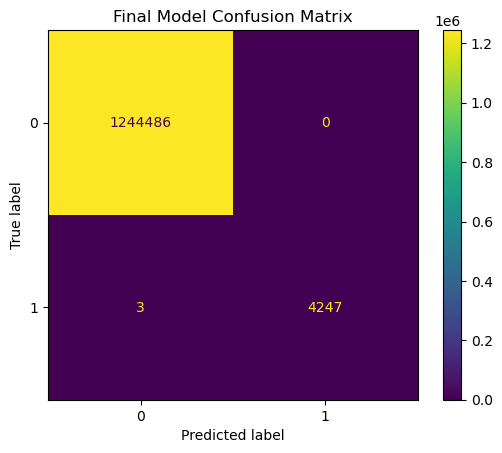

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    values_format="d"
)

plt.title("Final Model Confusion Matrix")
plt.show()

## 15. Feature Importance

In [34]:
feature_importance = (
    pd.Series(
        final_model.feature_importances_,
        index=engineered_features
    )
    .sort_values(ascending=False)
)

print(feature_importance)

amount_to_balance_ratio      0.395220
newbalanceOrig               0.139605
balance_change_orig          0.115627
origin_balance_error         0.100148
oldbalanceOrg                0.096888
newbalanceDest               0.062396
is_zero_balance_orig         0.041023
balance_change_dest          0.034821
destination_balance_error    0.005503
amount                       0.003853
day                          0.003604
oldbalanceDest               0.000530
hour                         0.000521
step                         0.000178
is_night                     0.000083
dtype: float32


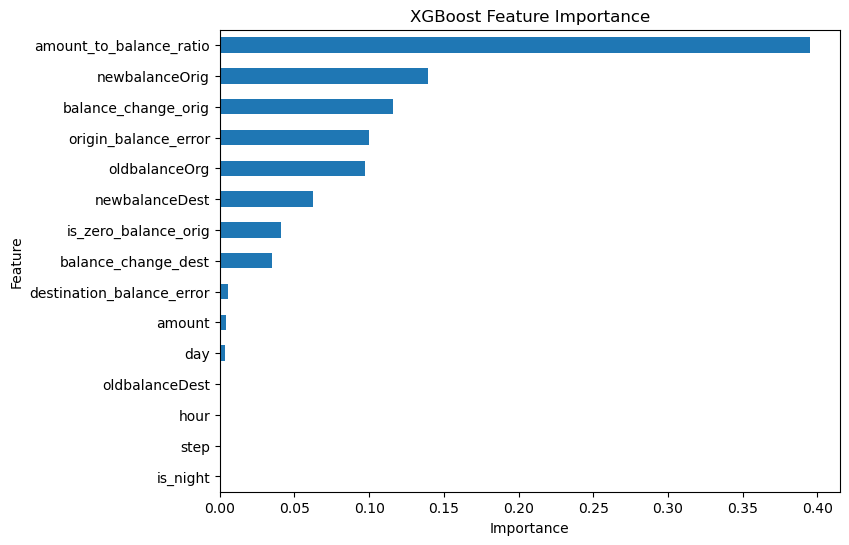

In [35]:
plt.figure(figsize=(8, 6))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 16. Final Results Summary

In [47]:
from sklearn.metrics import precision_score, recall_score, f1_score

final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)

final_results = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1 Score",
        "Average Precision (PR AUC)",
        "False Positives",
        "False Negatives"
    ],
    "Value": [
        final_precision,
        final_recall,
        final_f1,
        average_precision_score(y_test, y_test_prob),
        0,
        3
    ]
})

final_results

,Metric,Value
0,Precision,1.000000
1,Recall,0.999294
2,F1 Score,0.999647
3,Average Precision (PR AUC),0.999605
4,False Positives,0.000000
5,False Negatives,3.000000


## 17. Business Interpretation & Recommendations

The model demonstrates that engineered transaction and balance features are highly effective for identifying fraudulent transactions.

The strongest predictors are primarily related to the originating account's balance behaviour, including the amount-to-balance ratio, balance changes, and balance inconsistencies.

From a business perspective, the model could be used as a post-transaction fraud risk scoring system to prioritise suspicious transactions for investigation.


Key recommendations:

- Prioritise transactions with highly anomalous balance behaviour for review.
- Use model probabilities to rank transactions by fraud risk.
- Apply different decision thresholds depending on the cost of false positives and false negatives.
- Monitor model performance over time as transaction behaviour changes.
- Retrain the model periodically using newer transaction data.

## 18. Conclusion

This project developed an XGBoost-based fraud detection system using a highly imbalanced financial transaction dataset.

Feature engineering significantly improved fraud detection performance compared with the baseline model. On the held-out future test period, the final model achieved 99.93% fraud recall, 100% precision, and a 99.96% F1 score, with zero false positives and only three missed fraud cases.

The analysis showed that balance-related transaction features were the strongest predictors of fraud.

The model demonstrates the potential of machine learning to prioritise suspicious transactions for post-transaction fraud investigation.

Because the dataset is synthetic and the model uses post-transaction balance information, its performance should not be assumed to directly generalise to a real-world pre-authorisation fraud detection system.